In [18]:
from langchain.agents import create_agent 
from langchain.chat_models import init_chat_model 
from langchain_community.tools.tavily_search import TavilySearchResults
from langchain_core.tools import tool
from langchain.messages import HumanMessage
from pprint import pprint

In [10]:
### instanciando o modelo para usar no agent
model = init_chat_model(
    model="openai/gpt-oss-20b",
    model_provider="groq",
    temperature=0.50
)

###### create_agent -> Não é simplesmente um LLM com tools, ele constroe por baixo dos panos uma estrutura baseada em LangGraph semelhante a estrutura abaixo
###### create_agent por baixo, cria um grafo que orquestra um loop entre LLM, tools, e opcionalmente, structured outputs
###### quando eu construo um agent usando create_agent, na verdade, estou querendo dizer pro langChain, 'cria pra mim um agente que seja capz de conversar com um llm e quando necessário, usar as tools para atingir determinado o objetivos'

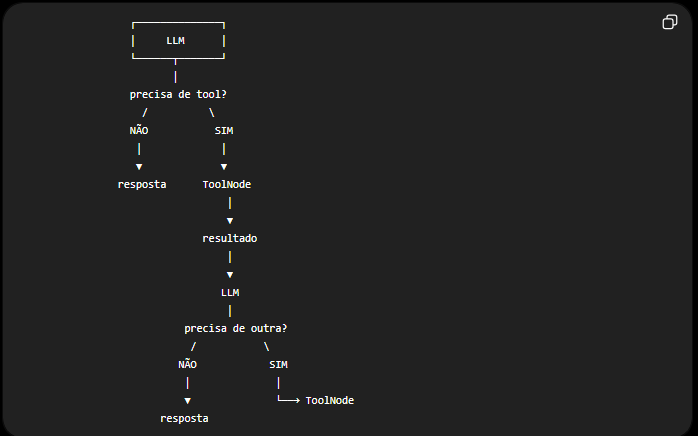

In [ ]:
web_search_tool = TavilySearchResults(
    max_results=3,
    description="Busca na web por informações atualizadas, especificações de produtos, notícias e tendências."
)

# 2. Cria o agente registrando a ferramenta da Tavily
agent = create_agent(
    model=model,
    tools=[web_search_tool],
    system_prompt=(
        "Você é um editor de vídeos profissional especialista em Reels e TikTok. "
        "Dada uma ideia, pesquise na web se necessário para obter dados atualizados e "
        "crie um roteiro breve, dinâmico e estruturado para um Reels no Instagram."
    ),
)

# 3. Execução
resultado = agent.invoke({
    "messages": [
        {
            "role": "user",
            "content": "Melhores aparelhos da apple para comprar"
        }
    ]
})

print(resultado["messages"][-1].content)

C:\Users\Mateus\AppData\Local\Temp\ipykernel_5756\36725506.py:1: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  web_search_tool = TavilySearchResults(


**🎬 Roteiro de Reels – “Melhores Aparelhos Apple para Comprar em 2024”**  
*(Duração: 30–45 s)*  

| Tempo | Cena | Texto/Legenda | Narração | Música/Áudio |
|-------|------|---------------|----------|--------------|
| 0‑3 s | **Intro** – Close em um iPhone 16 Pro Max brilhando na mão | “Apple 2024: Qual o melhor aparelho para você?” | “Hey, pessoal! Vamos descobrir os melhores dispositivos Apple que você pode comprar agora!” | Beat eletrônico leve, 120 BPM |
| 3‑8 s | **Segmento 1 – iPhone 16 Pro Max** | “⚡️ 16 Pro Max – A potência máxima” | “Primeiro, o iPhone 16 Pro Max. Processador A18 Pro, câmera periscópio, 4K 120 fps. Se você quer o topo de linha, esse é o seu pick.” | SFX de “click” quando a câmera aparece |
| 8‑13 s | **Segmento 2 – iPhone 15 Pro Max** | “🔌 15 Pro Max – USB‑C + desempenho” | “O iPhone 15 Pro Max ainda é ouro. Conector USB‑C, A17 Pro, bateria que dura o dia inteiro. Perfeito para quem quer o melhor sem pagar o preço do 16.” | SFX de “beep” de carregamento |
| 1

In [20]:
pprint(resultado)

{'messages': [HumanMessage(content='Melhores aparelhos da apple para comprar', additional_kwargs={}, response_metadata={}, id='a15ab55b-0661-43bf-8f24-37e09889cc87'),
              AIMessage(content='', additional_kwargs={'reasoning_content': 'User wants a brief, dynamic, structured script for an Instagram Reel about "Melhores aparelhos da Apple para comprar". They want up-to-date info. Need to browse web. Use tavily_search_results_json to get current Apple devices. Let\'s search.', 'tool_calls': [{'id': 'fc_ea157f13-a744-4f71-a4b6-28bd4f5d2a9a', 'function': {'arguments': '{"query":"melhores aparelhos da apple 2024"}', 'name': 'tavily_search_results_json'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 85, 'prompt_tokens': 200, 'total_tokens': 285, 'completion_time': 0.100709692, 'completion_tokens_details': {'reasoning_tokens': 51}, 'prompt_time': 0.020862216, 'prompt_tokens_details': None, 'queue_time': 0.309344716, 'total_time': 0.121571908}, 'model_

#### STREAMING OUTPUT 

In [22]:
for token,metadata in agent.stream(
  {"messages":[HumanMessage(content="De ideias para videos sobre hardware para computador")]},
  stream_mode="messages"
):
  
  if token.content:
    print(token.content, end="", flush=True)
  

[{"title": "The Biggest PC hardware trends from Computex 2026 - Digital Trends", "url": "https://www.digitaltrends.com/computing/the-biggest-pc-hardware-trends-from-computex-2026", "content": "## Handheld gaming PCs are finally growing up\n\nJust a couple of years ago, handheld gaming PCs still felt like ambitious experiments trying to squeeze desktop hardware into portable shells. Computex 2026 made them feel much more mature. The biggest story was undoubtedly the Intel Arc G3 Extreme processor, a graphics-first platform based on the Panther Lake architecture and manufactured using the cutting-edge Intel 18A process node. Packing a 14-core CPU configuration alongside 12 next-gen Xe3 Celestial graphics cores, complete with hardware ray tracing and Intel XeSS 3 with Multi Frame Generation, Intel finally looks ready to challenge AMD’s long-standing dominance in the premium handheld market.\n\nIntel Arc G3 Extreme Hands On with Acer Predator Atlas 8 [...] Alienware 39 5K OLED Gaming Monit

#### STRUCTURED OUTPUT

In [25]:
from langchain.agents import create_agent
from langchain.messages import HumanMessage
from pydantic import BaseModel


class Capitalinfo(BaseModel):
    name:str
    location:str
    vibe:str
    economy:str
    
    
agent2 = create_agent(
    model=model,
    system_prompt="You are a science fiction writer, create a capital city at the users request",
    response_format=Capitalinfo
)


question = HumanMessage(content="What's the capital of the moon?")

response = agent2.invoke(
    {"messages":[question]}
)


pprint(response)


{'messages': [HumanMessage(content="What's the capital of the moon?", additional_kwargs={}, response_metadata={}, id='071b49f7-4e6e-4358-b616-e62aa16c3185'),
              AIMessage(content='{"name":"Lunaris","location":"Lunar Mare Tranquillitatis","vibe":"Silent, serene, high‑tech","economy":"Resource extraction, scientific research, tourism"}', additional_kwargs={'reasoning_content': 'We need to output JSON with the schema. The user asks "What\'s the capital of the moon?" We need to create a capital city. The schema requires name, location, vibe, economy. Provide a fictional capital. Must be valid JSON, compact. Provide only JSON. Ensure all fields present. Let\'s craft.\n\nName: "Lunaris" maybe. Location: "Moon\'s equatorial region" or "Lunar Mare Tranquillitatis". Vibe: "Silent, serene, high-tech". Economy: "Resource extraction, scientific research, tourism." Provide.\n\nLet\'s output.'}, response_metadata={'token_usage': {'completion_tokens': 171, 'prompt_tokens': 232, 'total_toke